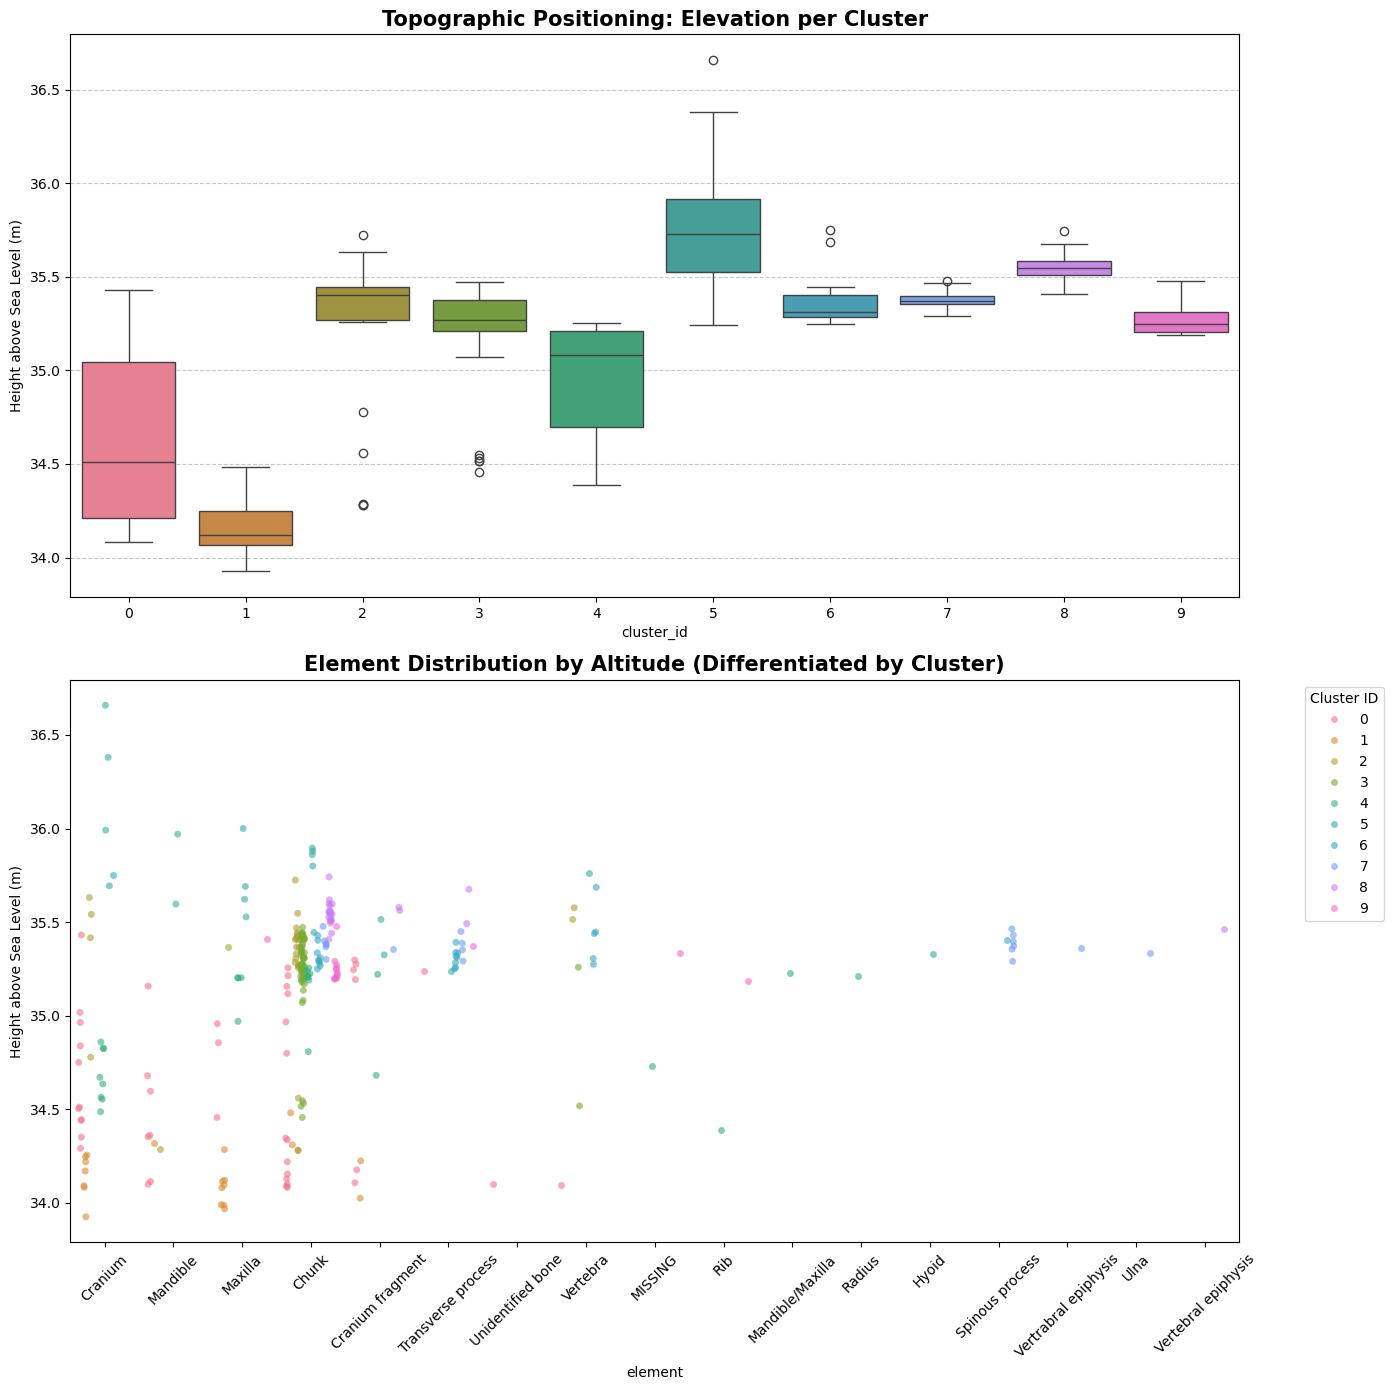

--- TOPOGRAPHIC SUMMARY (in meters) ---
                 mean   std        min        max
cluster_id                                       
0           34.630001  0.44  34.080002  35.430000
1           34.150002  0.14  33.930000  34.480000
2           35.250000  0.40  34.279999  35.720001
3           35.230000  0.24  34.459999  35.470001
4           34.950001  0.29  34.389999  35.259998
5           35.759998  0.35  35.240002  36.660000
6           35.360001  0.13  35.250000  35.750000
7           35.380001  0.05  35.290001  35.480000
8           35.549999  0.07  35.410000  35.740002
9           35.270000  0.09  35.189999  35.480000


In [4]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# =================================================================
# 1. SETTINGS
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Final_Analysis.gpkg')

# =================================================================
# 2. LOAD DATA
# =================================================================
whales = gpd.read_file(points_gpkg, layer='Whale_Points_Clustered')
whales_clustered = whales[whales['cluster_id'] != -1].copy()

# =================================================================
# 3. EXTRACT ELEVATION
# =================================================================
with rasterio.open(dem_path) as src:
    # Align CRS if necessary
    if whales_clustered.crs != src.crs:
        whales_clustered = whales_clustered.to_crs(src.crs)
    # Optimized coordinate list extraction
    coord_list = np.column_stack((whales_clustered.geometry.x, whales_clustered.geometry.y))
    whales_clustered['elevation'] = [val[0] for val in src.sample(coord_list)]

# =================================================================
# 4. ENHANCED VISUALIZATION
# =================================================================
# Wir definieren eine kontrastreiche Palette für alle Plots
num_clusters = len(whales_clustered['cluster_id'].unique())
cluster_palette = sns.color_palette("husl", num_clusters)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Plot A: Elevation per Cluster (Boxplot)
# Fix: hue zugewiesen und legend=False um die Warnung zu entfernen
sns.boxplot(
    data=whales_clustered, 
    x='cluster_id', 
    y='elevation', 
    hue='cluster_id', 
    ax=ax1, 
    palette=cluster_palette, 
    legend=False
)
ax1.set_title('Topographic Positioning: Elevation per Cluster', fontsize=15, fontweight='bold')
ax1.set_ylabel('Height above Sea Level (m)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot B: Skeletal Elements vs Elevation (Stripplot)
# Hier nutzen wir jitter und eine hohe Sättigung für bessere Sichtbarkeit
sns.stripplot(
    data=whales_clustered, 
    x='element', 
    y='elevation', 
    hue='cluster_id', 
    ax=ax2, 
    palette=cluster_palette,
    dodge=True,           # Trennt die Punkte der Cluster pro Element leicht auf
    alpha=0.6, 
    size=5,
    jitter=0.3
)
plt.xticks(rotation=45)
ax2.set_title('Element Distribution by Altitude (Differentiated by Cluster)', fontsize=15, fontweight='bold')
ax2.set_ylabel('Height above Sea Level (m)')
ax2.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'Whale_Topography_Analysis_HighRes.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print-Out für die numerische Relevanzprüfung
print("--- TOPOGRAPHIC SUMMARY (in meters) ---")
print(whales_clustered.groupby('cluster_id')['elevation'].agg(['mean', 'std', 'min', 'max']).round(2))


C:\Users\langm\AppData\Local\Temp\ipykernel_127756\3557703385.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


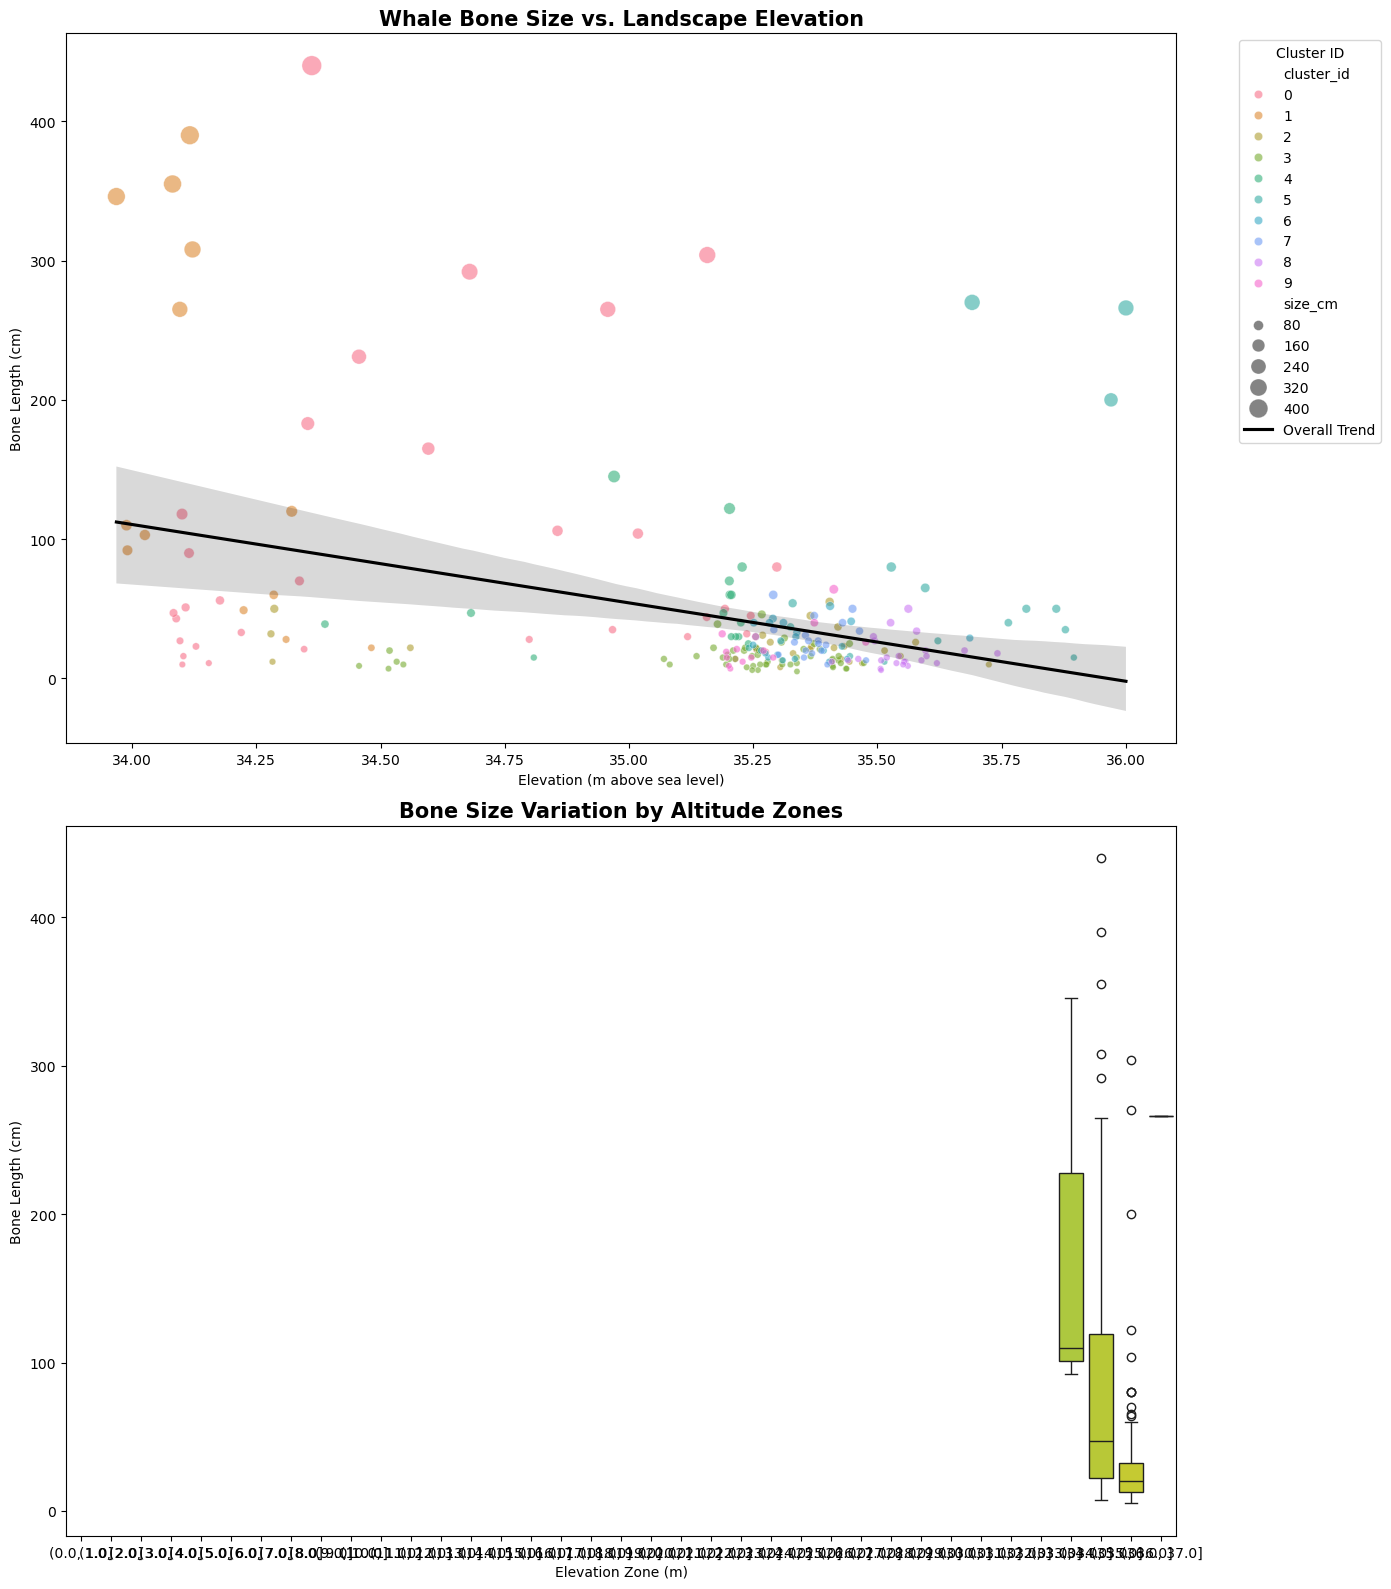


Pearson Correlation (Elevation vs. Size): -0.374

--- CLUSTER LOGISTICS SUMMARY ---
           size_cm        elevation
              mean count       mean
cluster_id                         
0            91.29    34  34.630001
1           172.92    13  34.150002
2            23.44    25  35.240002
3            15.05    56  35.230000
4            54.38    16  35.090000
5            77.44    16  35.650002
6            26.90    21  35.349998
7            28.26    19  35.380001
8            17.88    24  35.549999
9            23.21    14  35.270000


In [5]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# =================================================================
# 1. SETTINGS (Updated Paths)
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Final_Analysis.gpkg')
length_col = 'size_cm'

# =================================================================
# 2. LOAD & PREPARE DATA
# =================================================================
whales = gpd.read_file(points_gpkg, layer='Whale_Points_Clustered')
# Filter: Nur geclusterte Punkte mit gültigem Messwert
whales_clean = whales[(whales['cluster_id'] != -1)].copy()
whales_clean[length_col] = pd.to_numeric(whales_clean[length_col], errors='coerce')
whales_clean = whales_clean.dropna(subset=[length_col])

# =================================================================
# 3. EXTRACT ELEVATION
# =================================================================
with rasterio.open(dem_path) as src:
    # Align CRS if necessary
    if whales_clean.crs != src.crs:
        whales_clean = whales_clean.to_crs(src.crs)
    # Optimized coordinate list extraction
    coord_list = np.column_stack((whales_clean.geometry.x, whales_clean.geometry.y))
    whales_clean['elevation'] = [val[0] for val in src.sample(coord_list)]

# =================================================================
# 4. VISUALIZATION: SIZE VS TOPOGRAPHY
# =================================================================
num_clusters = len(whales_clean['cluster_id'].unique())
cluster_palette = sns.color_palette("husl", num_clusters)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16))

# Plot A: Scatterplot Size vs. Elevation (The "Logistics" Plot)
sns.scatterplot(
    data=whales_clean, 
    x='elevation', 
    y=length_col, 
    hue='cluster_id', 
    palette=cluster_palette,
    size=length_col, 
    sizes=(20, 200),
    alpha=0.6,
    ax=ax1
)
# Regressionslinie über alle Punkte, um einen allgemeinen Trend zu sehen
sns.regplot(data=whales_clean, x='elevation', y=length_col, scatter=False, color='black', ax=ax1, label='Overall Trend')

ax1.set_title('Whale Bone Size vs. Landscape Elevation', fontsize=15, fontweight='bold')
ax1.set_xlabel('Elevation (m above sea level)')
ax1.set_ylabel('Bone Length (cm)')
ax1.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot B: Size Distribution per Elevation-Bin
# Wir teilen die Höhe in 1m-Schritte ein, um Muster zu sehen
whales_clean['elev_bin'] = pd.cut(whales_clean['elevation'], bins=np.arange(0, whales_clean['elevation'].max()+1, 1))

sns.boxplot(
    data=whales_clean, 
    x='elev_bin', 
    y=length_col, 
    palette='viridis',
    ax=ax2
)
ax2.set_title('Bone Size Variation by Altitude Zones', fontsize=15, fontweight='bold')
ax2.set_xlabel('Elevation Zone (m)')
ax2.set_ylabel('Bone Length (cm)')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'Whale_Size_Topography_Correlation.png'), dpi=300, bbox_inches='tight')
plt.show()

# =================================================================
# 5. SUMMARY STATISTICS
# =================================================================
# Korrelation berechnen
corr = whales_clean['elevation'].corr(whales_clean[length_col])
print(f"\nPearson Correlation (Elevation vs. Size): {corr:.3f}")

summary = whales_clean.groupby('cluster_id').agg({
    length_col: ['mean', 'count'],
    'elevation': 'mean'
}).round(2)
print("\n--- CLUSTER LOGISTICS SUMMARY ---")
print(summary)


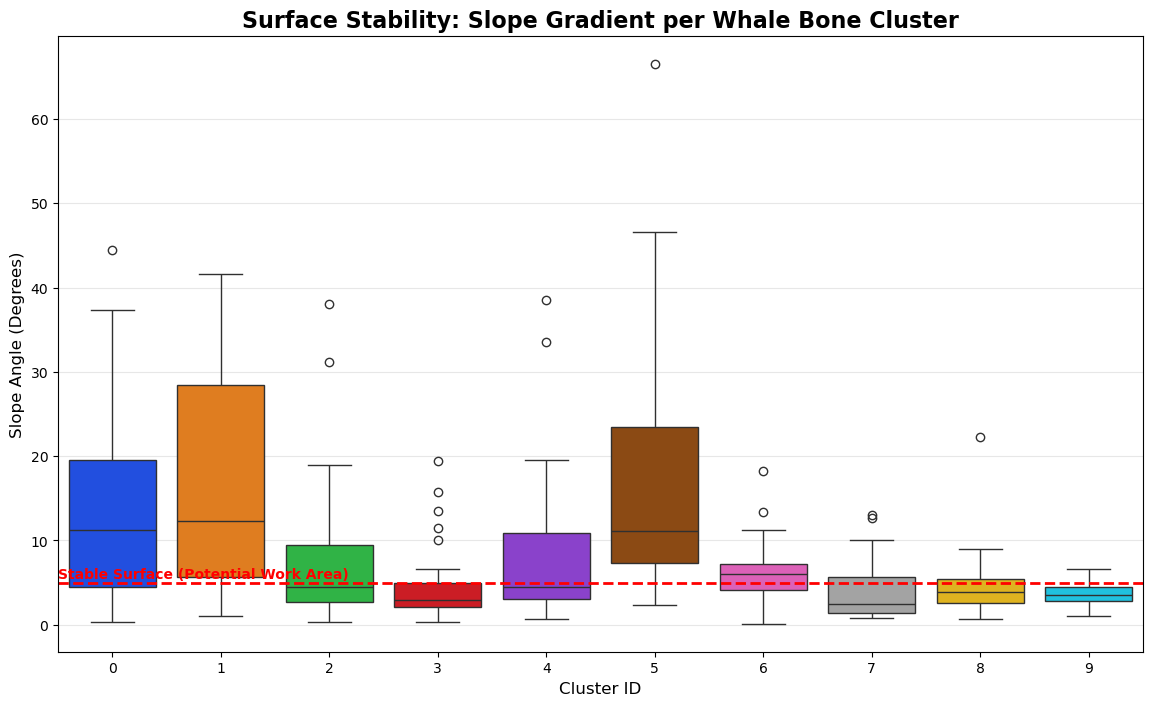

--- MEAN SLOPE AND STABILITY ---
                 mean        max        std
cluster_id                                 
0           13.670000  44.500000  10.940000
1           17.440001  41.660000  14.520000
2            7.910000  38.000000   8.910000
3            4.130000  19.459999   3.660000
4            8.810000  38.540001   9.440000
5           17.930000  66.550003  16.860001
6            6.340000  18.219999   3.820000
7            4.250000  13.040000   3.910000
8            4.890000  22.299999   4.290000
9            3.720000   6.620000   1.700000


In [7]:
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# =================================================================
# 1. SETTINGS
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Final_Analysis.gpkg')

# =================================================================
# 2. CALCULATE SLOPE RASTER
# =================================================================
with rasterio.open(dem_path) as dataset:
    dem_data = dataset.read(1)
    # Mask NoData values
    nodata = dataset.nodata
    if nodata is not None:
        dem_data = np.where(dem_data == nodata, np.nan, dem_data)
        
    res_x, res_y = dataset.res
    transform = dataset.transform
    
    # Gradienten berechnen
    dy, dx = np.gradient(dem_data, res_y, res_x)
    # Slope in Grad berechnen
    slope_array = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi)

# =================================================================
# 3. LOAD DATA & SAMPLE SLOPE
# =================================================================
whales = gpd.read_file(points_gpkg, layer='Whale_Points_Clustered')
whales_clustered = whales[whales['cluster_id'] != -1].copy()

# Ensure coordinates match the raster CRS
with rasterio.open(dem_path) as dataset:
    if whales_clustered.crs != dataset.crs:
        whales_clustered = whales_clustered.to_crs(dataset.crs)
    transform = dataset.transform

# Korrektur für den TypeError: Wir berechnen die Zeilen/Spalten Indizes einzeln
# oder nutzen die robuste rowcol-Funktion von rasterio
rows, cols = rowcol(transform, whales_clustered.geometry.x, whales_clustered.geometry.y)

# Werte aus dem Slope-Array extrahieren
# Wir müssen sicherstellen, dass die Indizes innerhalb des Arrays liegen
rows = np.clip(rows, 0, slope_array.shape[0] - 1)
cols = np.clip(cols, 0, slope_array.shape[1] - 1)
whales_clustered['slope_deg'] = slope_array[rows, cols]

# =================================================================
# 4. VISUALIZATION
# =================================================================
# Wir nutzen eine sehr kontrastreiche Palette für die Cluster
num_clusters = len(whales_clustered['cluster_id'].unique())
cluster_palette = sns.color_palette("bright", num_clusters)

plt.figure(figsize=(14, 8))

# Boxplot mit korrekten hue/legend Einstellungen
sns.boxplot(
    data=whales_clustered, 
    x='cluster_id', 
    y='slope_deg', 
    hue='cluster_id', 
    palette=cluster_palette, 
    legend=False
)

# Kritische Schwelle für Hangstabilität (5 Grad)
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Stability Threshold (5°)')
plt.text(-0.5, 5.5, 'Stable Surface (Potential Work Area)', color='red', fontweight='bold')

plt.title('Surface Stability: Slope Gradient per Whale Bone Cluster', fontsize=16, fontweight='bold')
plt.ylabel('Slope Angle (Degrees)', fontsize=12)
plt.xlabel('Cluster ID', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Speichern
output_img = os.path.join(base_path, 'Whale_Slope_Analysis_Fixed.png')
plt.savefig(output_img, dpi=300, bbox_inches='tight')
plt.show()

# Numerischer Check für die "ehrliche Meinung"
print("--- MEAN SLOPE AND STABILITY ---")
stats = whales_clustered.groupby('cluster_id')['slope_deg'].agg(['mean', 'max', 'std']).round(2)
print(stats)
